# Federated Learning - Kronolojik Eğitim

## Yapı
- **3 client** (User 1, 2, 3), her biri kendi telefonundaki verileri tutuyor
- **6 round**, her round'da 5 günlük veri penceresi (30 gün / 6 = 5 gün)
- Her round: Global model dağıtılır → Client'lar local eğitim yapar → FedAvg ile aggregate

## Parametreler
| Parametre | Değer |
|-----------|-------|
| Round | 6 |
| Veri/round | 5 gün (~350 kayıt/client) |
| Local epochs | 20 |
| Batch size | 32 |
| Learning rate | 0.01 |
| Aggregation | FedAvg (eşit ağırlıklı ortalama) |

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
import math
import os
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cpu


## 1. Veri Yükleme ve Kronolojik Pencereler

30 günü 6 pencereye bölüyoruz. Her pencere 5 gün.

In [ ]:
APP_TO_IDX = {
    "com.instagram.android": 0,
    "com.google.android.youtube": 1,
    "com.linkedin.android": 2,
    "com.whatsapp": 3
}
IDX_TO_LABEL = {0: "Instagram", 1: "YouTube", 2: "LinkedIn", 3: "WhatsApp"}
LOCAL_TZ = "Europe/Istanbul"
NUM_ROUNDS = 6
DAYS_PER_ROUND = 5

USER_FILES = {
    "user1": "app_usage_data_user1.csv",
    "user2": "app_usage_data_user2.csv",
    "user3": "app_usage_data_user3.csv"
}

def load_full_data(csv_path):
    df = pd.read_csv(csv_path)
    df["datetime"] = (
        pd.to_datetime(df["timestamp"], unit="ms", utc=True)
          .dt.tz_convert(LOCAL_TZ)
    )
    df["date"] = df["datetime"].dt.date
    df["hour"] = df["datetime"].dt.hour + df["datetime"].dt.minute / 60.0
    df["sin_hour"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["cos_hour"] = np.cos(2 * np.pi * df["hour"] / 24.0)
    df["label"] = df["packageName"].map(APP_TO_IDX)
    return df

def split_by_days(df, days_per_round=5):
    """Kronolojik olarak gün bazlı pencerelere böler."""
    all_days = sorted(df["date"].unique())
    windows = []
    for i in range(0, len(all_days), days_per_round):
        window_days = all_days[i:i + days_per_round]
        window_df = df[df["date"].isin(window_days)]
        X = window_df[["sin_hour", "cos_hour"]].values.astype(np.float32)
        y = window_df["label"].values.astype(np.int64)
        windows.append({
            "X": X, "y": y,
            "days": window_days,
            "n_records": len(X)
        })
    return windows

user_windows = {}
for user, path in USER_FILES.items():
    df = load_full_data(path)
    windows = split_by_days(df, DAYS_PER_ROUND)
    user_windows[user] = windows
    print(f"\n{user}: {len(windows)} pencere")
    for i, w in enumerate(windows):
        print(f"  Round {i+1}: Gun {w['days'][0]} -> {w['days'][-1]} ({w['n_records']} kayit)")


user1: 6 pencere
  Round 1: Gun 2026-01-19 -> 2026-01-23 (376 kayit)
  Round 2: Gun 2026-01-24 -> 2026-01-28 (374 kayit)
  Round 3: Gun 2026-01-29 -> 2026-02-02 (376 kayit)
  Round 4: Gun 2026-02-03 -> 2026-02-07 (397 kayit)
  Round 5: Gun 2026-02-08 -> 2026-02-12 (365 kayit)
  Round 6: Gun 2026-02-13 -> 2026-02-17 (401 kayit)

user2: 6 pencere
  Round 1: Gun 2026-01-19 -> 2026-01-23 (354 kayit)
  Round 2: Gun 2026-01-24 -> 2026-01-28 (371 kayit)
  Round 3: Gun 2026-01-29 -> 2026-02-02 (351 kayit)
  Round 4: Gun 2026-02-03 -> 2026-02-07 (344 kayit)
  Round 5: Gun 2026-02-08 -> 2026-02-12 (376 kayit)
  Round 6: Gun 2026-02-13 -> 2026-02-17 (332 kayit)

user3: 6 pencere
  Round 1: Gun 2026-01-19 -> 2026-01-23 (371 kayit)
  Round 2: Gun 2026-01-24 -> 2026-01-28 (352 kayit)
  Round 3: Gun 2026-01-29 -> 2026-02-02 (357 kayit)
  Round 4: Gun 2026-02-03 -> 2026-02-07 (365 kayit)
  Round 5: Gun 2026-02-08 -> 2026-02-12 (365 kayit)
  Round 6: Gun 2026-02-13 -> 2026-02-17 (361 kayit)


## 2. Model + Local Training + FedAvg

In [ ]:
class AppUsageModel(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, output_dim=4):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

    def predict_proba(self, x):
        with torch.no_grad():
            logits = self.forward(x)
            return torch.softmax(logits, dim=1)


def local_train(global_state_dict, X, y, local_epochs=20, batch_size=32, lr=0.01):
    """
    Client tarafinda local egitim.
    Global model weight'lerinden baslar, local veriyle egitir, guncel weight dondurur.
    """
    model = AppUsageModel().to(device)
    model.load_state_dict(copy.deepcopy(global_state_dict))

    X_t = torch.FloatTensor(X).to(device)
    y_t = torch.LongTensor(y).to(device)

    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))

    model.train()
    for epoch in range(local_epochs):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_t).argmax(dim=1)
        acc = (preds == y_t).float().mean().item()

    return model.state_dict(), acc, len(X)


def fed_avg(client_state_dicts, client_sizes):
    """
    FedAvg: Client weight'lerini veri buyuklugune gore agirlikli ortalama ile birlestirir.
    """
    total = sum(client_sizes)
    weights = [s / total for s in client_sizes]

    avg_state = {}
    for key in client_state_dicts[0]:
        avg_state[key] = sum(
            w * client_state_dicts[i][key].float()
            for i, w in enumerate(weights)
        )
    return avg_state


def predict_for_hours(model, hours):
    """24 saat icin tahmin tablosu olusturur."""
    results = []
    model.eval()
    for h in hours:
        sin_h = math.sin(2 * math.pi * h / 24.0)
        cos_h = math.cos(2 * math.pi * h / 24.0)
        x = torch.FloatTensor([[sin_h, cos_h]]).to(device)
        probs = model.predict_proba(x)[0].cpu().numpy()
        pred_idx = probs.argmax()
        results.append({
            "hour": h, "prediction": IDX_TO_LABEL[pred_idx],
            "confidence": probs[pred_idx], "probs": probs
        })
    return results


def print_predictions(results, title=""):
    """Tahmin tablosunu yazdirir."""
    if title:
        print(title)
    print(f" {'saat':>5}  {'tahmin':>9} {'guven':>5}  {'Insta':>6} {'YT':>6} {'Link':>6} {'WA':>6}")
    for r in results:
        p = r["probs"]
        print(f" {r['hour']:02d}:00  {r['prediction']:>9} {r['confidence']*100:4.1f}%  "
              f"{p[0]*100:5.1f}% {p[1]*100:5.1f}% {p[2]*100:5.1f}% {p[3]*100:5.1f}%")


print("Model parametreleri:", sum(p.numel() for p in AppUsageModel().parameters()))

Model parametreleri: 388


## 3. Federated Learning - 6 Round

Her round sonunda global modelin 24-saat predict tablosunu basıyoruz.

In [ ]:
global_model = AppUsageModel().to(device)
global_state = global_model.state_dict()

round_history = []

for r in range(NUM_ROUNDS):
    print(f"\n{'#'*70}")
    print(f"  ROUND {r+1}/{NUM_ROUNDS}")
    print(f"{'#'*70}")

    client_states = []
    client_sizes = []

    for user in ["user1", "user2", "user3"]:
        window = user_windows[user][r]
        X, y = window["X"], window["y"]
        days = window["days"]

        state, acc, n = local_train(global_state, X, y, local_epochs=20, batch_size=32, lr=0.01)
        client_states.append(state)
        client_sizes.append(n)

        print(f"  {user}: Gun {days[0]}..{days[-1]} | {n:3d} kayit | Local Acc: {acc*100:.1f}%")

    global_state = fed_avg(client_states, client_sizes)

    global_model.load_state_dict(global_state)
    global_model.eval()

    results = predict_for_hours(global_model, range(24))
    round_history.append({"round": r+1, "results": results, "state": copy.deepcopy(global_state)})

    print(f"\n  --- Global Model (Round {r+1}) Tahminleri ---")
    print_predictions(results)

print(f"\n{'#'*70}")
print(f"  FEDERATED LEARNING TAMAMLANDI")
print(f"{'#'*70}")


######################################################################
  ROUND 1/6
######################################################################


  user1: Gun 2026-01-19..2026-01-23 | 376 kayit | Local Acc: 41.0%


  user2: Gun 2026-01-19..2026-01-23 | 354 kayit | Local Acc: 43.5%


  user3: Gun 2026-01-19..2026-01-23 | 371 kayit | Local Acc: 57.4%

  --- Global Model (Round 1) Tahminleri ---
  saat     tahmin guven   Insta     YT   Link     WA
 00:00    YouTube 40.2%   27.8%  40.2%   4.6%  27.5%
 01:00    YouTube 41.0%   22.0%  41.0%   5.5%  31.5%
 02:00    YouTube 41.8%   17.5%  41.8%   5.8%  34.8%
 03:00    YouTube 42.4%   16.0%  42.4%   5.2%  36.5%
 04:00    YouTube 41.7%   16.5%  41.7%   4.3%  37.5%
 05:00    YouTube 39.6%   19.1%  39.6%   3.5%  37.8%
 06:00   WhatsApp 38.2%   21.5%  37.3%   3.0%  38.2%
 07:00   WhatsApp 37.5%   25.6%  34.2%   2.8%  37.5%
 08:00   WhatsApp 35.9%   30.0%  31.3%   2.8%  35.9%
 09:00   WhatsApp 35.3%   30.9%  29.0%   4.8%  35.3%
 10:00   WhatsApp 32.9%   31.5%  26.3%   9.3%  32.9%
 11:00   WhatsApp 31.4%   26.5%  25.9%  16.1%  31.4%
 12:00   WhatsApp 32.1%   23.2%  22.4%  22.3%  32.1%
 13:00   WhatsApp 33.3%   20.8%  19.1%  26.8%  33.3%
 14:00   WhatsApp 33.2%   18.8%  17.5%  30.4%  33.2%
 15:00   WhatsApp 32.7%   19.4%  17.0%  

  user1: Gun 2026-01-24..2026-01-28 | 374 kayit | Local Acc: 41.7%


...

  user2: Gun 2026-02-08..2026-02-12 | 376 kayit | Local Acc: 49.2%


  user3: Gun 2026-02-08..2026-02-12 | 365 kayit | Local Acc: 61.1%

  --- Global Model (Round 5) Tahminleri ---
  saat     tahmin guven   Insta     YT   Link     WA
 00:00  Instagram 40.2%   40.2%  23.6%   5.4%  30.8%
 01:00  Instagram 37.2%   37.2%  24.2%   8.0%  30.6%
 02:00  Instagram 34.3%   34.3%  23.6%  11.0%  31.1%
 03:00   WhatsApp 35.0%   27.6%  25.2%  12.3%  35.0%
 04:00   WhatsApp 36.5%   24.2%  24.9%  14.4%  36.5%
 05:00   WhatsApp 36.1%   24.7%  24.1%  15.1%  36.1%
 06:00   WhatsApp 36.1%   30.5%  22.0%  11.4%  36.1%
 07:00   WhatsApp 38.1%   35.0%  20.0%   6.9%  38.1%
 08:00   WhatsApp 45.7%   30.8%  18.9%   4.6%  45.7%
 09:00   WhatsApp 55.3%    8.8%  26.6%   9.3%  55.3%
 10:00   LinkedIn 34.5%   13.6%  22.7%  34.5%  29.2%
 11:00   WhatsApp 28.3%   20.6%  23.3%  27.8%  28.3%
 12:00  Instagram 27.9%   27.9%  20.2%  24.9%  27.0%
 13:00  Instagram 42.4%   42.4%  13.6%  20.4%  23.6%
 14:00   WhatsApp 30.3%   28.2%  12.7%  28.7%  30.3%
 15:00   LinkedIn 40.7%   10.3%  11.5%  

  user1: Gun 2026-02-13..2026-02-17 | 401 kayit | Local Acc: 44.4%


  user2: Gun 2026-02-13..2026-02-17 | 332 kayit | Local Acc: 48.8%


  user3: Gun 2026-02-13..2026-02-17 | 361 kayit | Local Acc: 60.4%

  --- Global Model (Round 6) Tahminleri ---
  saat     tahmin guven   Insta     YT   Link     WA
 00:00  Instagram 37.3%   37.3%  27.4%   5.5%  29.8%
 01:00  Instagram 44.7%   44.7%  24.5%   6.2%  24.7%
 02:00    YouTube 35.1%   23.8%  35.1%   6.8%  34.3%
 03:00   WhatsApp 38.9%   15.2%  38.0%   8.0%  38.9%
 04:00   WhatsApp 40.1%   12.8%  36.4%  10.6%  40.1%
 05:00   WhatsApp 39.3%   13.7%  35.5%  11.5%  39.3%
 06:00    YouTube 34.8%   22.0%  34.8%   8.6%  34.6%
 07:00  Instagram 40.2%   40.2%  30.5%   3.2%  26.0%
 08:00  Instagram 46.3%   46.3%  25.8%   1.1%  26.8%
 09:00   WhatsApp 41.2%   25.9%  29.9%   3.0%  41.2%
 10:00   LinkedIn 32.1%   26.5%  17.1%  32.1%  24.4%
 11:00   LinkedIn 30.2%   27.6%  17.3%  30.2%  24.8%
 12:00   LinkedIn 32.4%   24.0%  18.3%  32.4%  25.3%
 13:00  Instagram 36.7%   36.7%  17.7%  24.4%  21.3%
 14:00   LinkedIn 31.2%   21.4%  19.7%  31.2%  27.7%
 15:00   LinkedIn 37.0%   10.9%  16.5%  

## 4. Final Global Model - Detaylı Karşılaştırma

Her kullanıcının beklenen pattern'lerine karşı final global modelin tahminleri.

In [ ]:
expected_patterns = {
    "user1": "08-10: %100 Instagram | 14-18: LinkedIn+WhatsApp | 18-20: YouTube+Instagram",
    "user2": "08-10: %100 YouTube | 12-14: %100 Instagram | 14-18: LinkedIn+WhatsApp",
    "user3": "08-10: %100 WhatsApp | 18-22: %100 YouTube | 22-02: Instagram"
}

print("="*70)
print("  FINAL GLOBAL MODEL vs BIREYSEL BEKLENTILER")
print("="*70)

final_results = round_history[-1]["results"]

for user, pattern in expected_patterns.items():
    print(f"\n  {user.upper()} beklentisi: {pattern}")

print(f"\n{'='*70}")
print(f"  GLOBAL MODEL - 24 SAAT TAHMIN TABLOSU")
print(f"{'='*70}")
print_predictions(final_results)

print(f"\n{'='*70}")
print("  SABIT ETKI SAATLERI - OZET")
print(f"{'='*70}")

checks = [
    ("08:00-10:00", [8, 9], {
        "user1": "Instagram",
        "user2": "YouTube",
        "user3": "WhatsApp"
    }),
    ("12:00-14:00", [12, 13], {
        "user2": "Instagram"
    }),
    ("18:00-22:00", [18, 19, 20, 21], {
        "user3": "YouTube"
    }),
]

for label, hours, user_expected in checks:
    print(f"\n  {label}:")
    for h in hours:
        r = final_results[h]
        p = r["probs"]
        expected_apps = [f"{u}: {app}" for u, app in user_expected.items()]
        print(f"    {h:02d}:00 -> {r['prediction']} ({r['confidence']*100:.1f}%)  "
              f"[Insta:{p[0]*100:.0f}% YT:{p[1]*100:.0f}% Link:{p[2]*100:.0f}% WA:{p[3]*100:.0f}%]  "
              f"Beklenen: {', '.join(expected_apps)}")

  FINAL GLOBAL MODEL vs BIREYSEL BEKLENTILER

  USER1 beklentisi: 08-10: %100 Instagram | 14-18: LinkedIn+WhatsApp | 18-20: YouTube+Instagram

  USER2 beklentisi: 08-10: %100 YouTube | 12-14: %100 Instagram | 14-18: LinkedIn+WhatsApp

  USER3 beklentisi: 08-10: %100 WhatsApp | 18-22: %100 YouTube | 22-02: Instagram

  GLOBAL MODEL - 24 SAAT TAHMIN TABLOSU
  saat     tahmin guven   Insta     YT   Link     WA
 00:00  Instagram 37.3%   37.3%  27.4%   5.5%  29.8%
 01:00  Instagram 44.7%   44.7%  24.5%   6.2%  24.7%
 02:00    YouTube 35.1%   23.8%  35.1%   6.8%  34.3%
 03:00   WhatsApp 38.9%   15.2%  38.0%   8.0%  38.9%
 04:00   WhatsApp 40.1%   12.8%  36.4%  10.6%  40.1%
 05:00   WhatsApp 39.3%   13.7%  35.5%  11.5%  39.3%
 06:00    YouTube 34.8%   22.0%  34.8%   8.6%  34.6%
 07:00  Instagram 40.2%   40.2%  30.5%   3.2%  26.0%
 08:00  Instagram 46.3%   46.3%  25.8%   1.1%  26.8%
 09:00   WhatsApp 41.2%   25.9%  29.9%   3.0%  41.2%
 10:00   LinkedIn 32.1%   26.5%  17.1%  32.1%  24.4%
 11:00

## 5. Round Bazlı Evrim - Sabit Saatlerin Değişimi

Her round sonunda kritik saatlerdeki tahminlerin nasıl değiştiğini takip edelim.

In [ ]:
critical_hours = {
    9: "08-10 blogu (U1:Insta, U2:YT, U3:WA)",
    13: "12-14 blogu (U2:Insta)",
    20: "18-22 blogu (U3:YT)",
    0: "22-02 blogu (U3:Insta)"
}

print("="*70)
print("  ROUND BAZLI EVRIM - KRITIK SAATLER")
print("="*70)

for hour, desc in critical_hours.items():
    print(f"\n  Saat {hour:02d}:00 - {desc}")
    print(f"  {'Round':>5}  {'Tahmin':>9}  {'Insta':>6} {'YT':>6} {'Link':>6} {'WA':>6}")
    for rh in round_history:
        r = rh["results"][hour]
        p = r["probs"]
        print(f"  R{rh['round']:>4}  {r['prediction']:>9}  "
              f"{p[0]*100:5.1f}% {p[1]*100:5.1f}% {p[2]*100:5.1f}% {p[3]*100:5.1f}%")

  ROUND BAZLI EVRIM - KRITIK SAATLER

  Saat 09:00 - 08-10 blogu (U1:Insta, U2:YT, U3:WA)
  Round     Tahmin   Insta     YT   Link     WA
  R   1   WhatsApp   30.9%  29.0%   4.8%  35.3%
  R   2   WhatsApp   18.1%  32.1%   3.4%  46.3%
  R   3   WhatsApp   22.4%  26.3%   6.0%  45.4%
  R   4   WhatsApp   13.7%  27.8%   4.1%  54.4%
  R   5   WhatsApp    8.8%  26.6%   9.3%  55.3%
  R   6   WhatsApp   25.9%  29.9%   3.0%  41.2%

  Saat 13:00 - 12-14 blogu (U2:Insta)
  Round     Tahmin   Insta     YT   Link     WA
  R   1   WhatsApp   20.8%  19.1%  26.8%  33.3%
  R   2   LinkedIn   16.5%  11.3%  41.0%  31.2%
  R   3  Instagram   31.6%  13.8%  29.7%  24.8%
  R   4  Instagram   39.5%  16.3%  24.3%  19.9%
  R   5  Instagram   42.4%  13.6%  20.4%  23.6%
  R   6  Instagram   36.7%  17.7%  24.4%  21.3%

  Saat 20:00 - 18-22 blogu (U3:YT)
  Round     Tahmin   Insta     YT   Link     WA
  R   1    YouTube   25.1%  47.0%   4.8%  23.1%
  R   2    YouTube   17.4%  61.4%   4.3%  16.9%
  R   3    YouTube 

## 6. Global Model Ağırlıklarını Kaydet

In [ ]:
os.makedirs("weights", exist_ok=True)

def save_weights_json(state_dict, filepath):
    serializable = {}
    for key, tensor in state_dict.items():
        serializable[key] = tensor.cpu().tolist()
    with open(filepath, "w") as f:
        json.dump(serializable, f, indent=2)
    print(f"  Kaydedildi: {filepath}")

for rh in round_history:
    save_weights_json(rh["state"], f"weights/global_round{rh['round']}_weights.json")

save_weights_json(round_history[-1]["state"], "weights/global_final_weights.json")

print("\nKaydedilen dosyalar:")
for f in sorted(os.listdir("weights")):
    if f.startswith("global"):
        size_kb = os.path.getsize(f"weights/{f}") / 1024
        print(f"  {f}: {size_kb:.1f} KB")

  Kaydedildi: weights/global_round1_weights.json
  Kaydedildi: weights/global_round2_weights.json
  Kaydedildi: weights/global_round3_weights.json
  Kaydedildi: weights/global_round4_weights.json
  Kaydedildi: weights/global_round5_weights.json
  Kaydedildi: weights/global_round6_weights.json
  Kaydedildi: weights/global_final_weights.json

Kaydedilen dosyalar:
  global_final_weights.json: 11.2 KB
  global_round1_weights.json: 11.3 KB
  global_round2_weights.json: 11.3 KB
  global_round3_weights.json: 11.2 KB
  global_round4_weights.json: 11.3 KB
  global_round5_weights.json: 11.2 KB
  global_round6_weights.json: 11.2 KB


## 7. Training Loss Evrimi

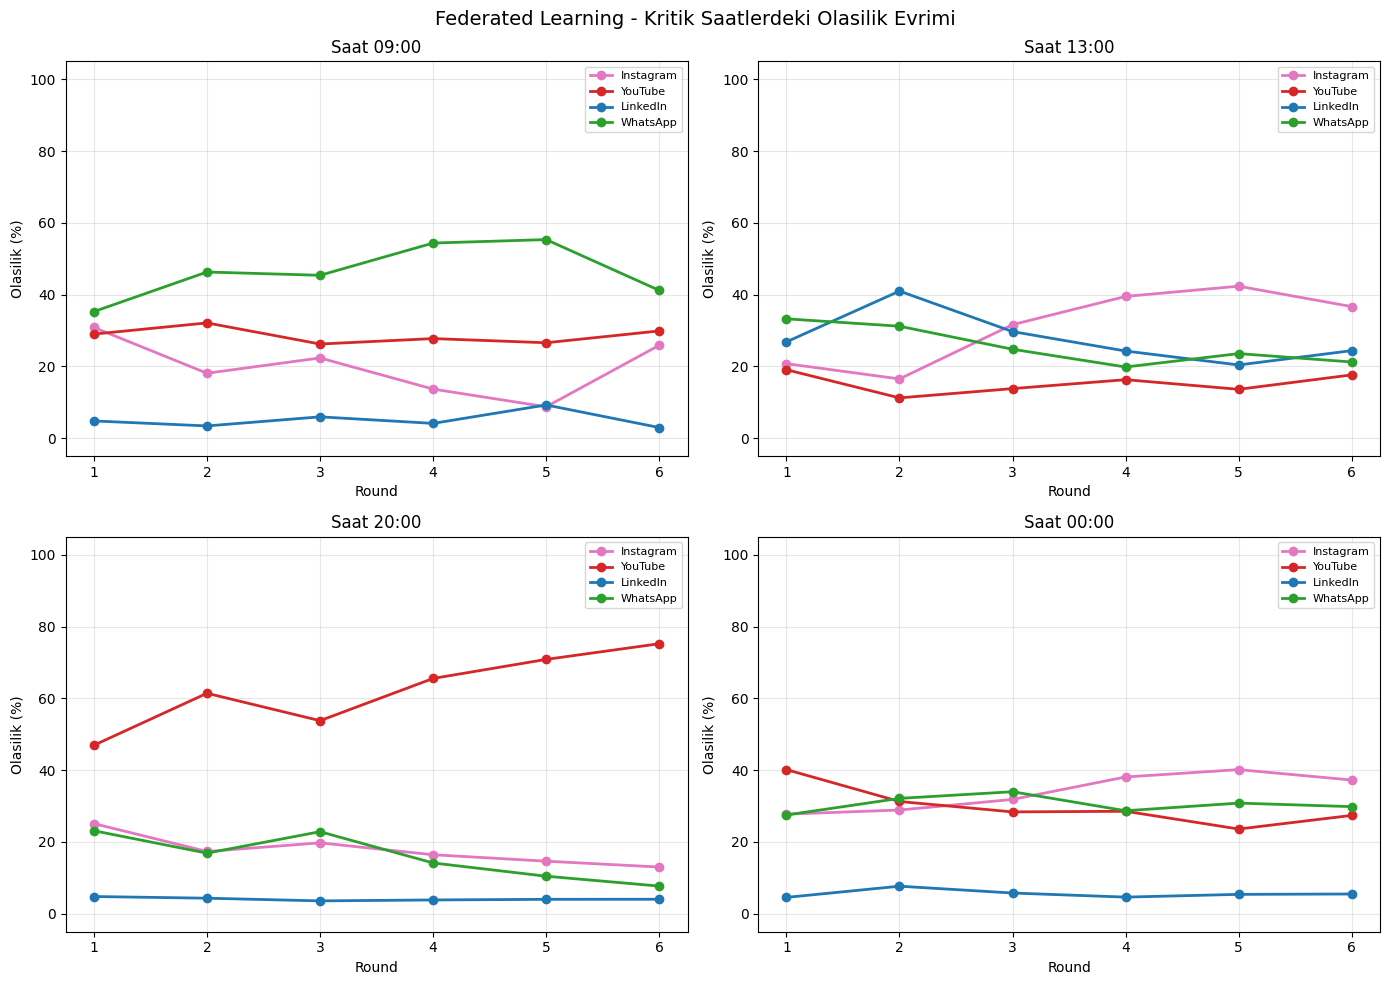

Grafik kaydedildi: fl_evolution.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

critical = {9: ("09:00", axes[0, 0]), 13: ("13:00", axes[0, 1]),
            20: ("20:00", axes[1, 0]), 0: ("00:00", axes[1, 1])}

app_colors = {"Instagram": "tab:pink", "YouTube": "tab:red",
              "LinkedIn": "tab:blue", "WhatsApp": "tab:green"}

for hour, (label, ax) in critical.items():
    rounds = [rh["round"] for rh in round_history]
    for app_idx, app_name in IDX_TO_LABEL.items():
        probs = [rh["results"][hour]["probs"][app_idx] * 100 for rh in round_history]
        ax.plot(rounds, probs, marker="o", label=app_name, color=app_colors[app_name], linewidth=2)
    ax.set_title(f"Saat {label}")
    ax.set_xlabel("Round")
    ax.set_ylabel("Olasilik (%)")
    ax.set_ylim(-5, 105)
    ax.set_xticks(rounds)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Federated Learning - Kritik Saatlerdeki Olasilik Evrimi", fontsize=14)
plt.tight_layout()
plt.savefig("fl_evolution.png", dpi=150)
plt.show()
print("Grafik kaydedildi: fl_evolution.png")